In [25]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make project root importable whether CWD is repo root or notebooks/
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / 'src').exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.io import load_run, load_runs

from src.preprocess import qc_report as build_qc_report


In [26]:
# Pick one run for QC
RUN_DIR = PROJECT_ROOT / 'data' / 'raw' / 'test' / 'log_20260209_125910.654'
run = load_run(RUN_DIR, include_pose=False)
acc, gyro, odo = run.acc, run.gyro, run.odo

print('Run:', run.run_id)
for name, df in [('acc', acc), ('gyro', gyro), ('odo', odo)]:
    print(f'{name}: n={len(df)}, t_rel=[{df.t_rel.min():.3f}, {df.t_rel.max():.3f}] s')

acc.head(), gyro.head(), odo.head()


Run: log_20260209_125910.654
acc: n=29643, t_rel=[0.000, 355.707] s
gyro: n=29986, t_rel=[0.000, 359.821] s
odo: n=45205, t_rel=[0.000, 361.634] s


(              t      ax      ay      az   t_rel
 0  1.770638e+09 -0.1358  0.5183  0.8604  0.0002
 1  1.770638e+09 -0.1314  0.5161  0.8628  0.0123
 2  1.770638e+09 -0.1348  0.5171  0.8606  0.0245
 3  1.770638e+09 -0.1344  0.5156  0.8731  0.0364
 4  1.770638e+09 -0.1348  0.5166  0.8624  0.0484,
               t      gx      gy      gz   t_rel
 0  1.770638e+09 -3.4322 -9.8548 -1.6905  0.0000
 1  1.770638e+09 -3.4617 -9.5496 -1.6984  0.0112
 2  1.770638e+09 -3.5501 -9.5496 -1.7221  0.0233
 3  1.770638e+09 -3.7449 -9.4581 -1.5848  0.0353
 4  1.770638e+09 -3.4890 -9.5496 -1.8321  0.0472,
               t   v1   v2   t_rel
 0  1.770638e+09 -0.0  0.0  0.0001
 1  1.770638e+09 -0.0  0.0  0.0078
 2  1.770638e+09 -0.0  0.0  0.0157
 3  1.770638e+09 -0.0  0.0  0.0244
 4  1.770638e+09 -0.0  0.0  0.0320)

In [27]:
def qc(df, tcol='t_rel'):
    if len(df) < 2:
        return {'n': int(len(df)), 'error': 'not enough samples'}

    dt = df[tcol].diff().dropna().to_numpy()
    dt = dt[np.isfinite(dt)]
    if dt.size == 0:
        return {'n': int(len(df)), 'error': 'invalid dt values'}

    med = float(np.median(dt))
    fs = float(1.0 / med) if med > 0 else float('nan')
    return {
        'n': int(len(df)),
        'duration_s': float(df[tcol].iloc[-1] - df[tcol].iloc[0]),
        'fs_med_hz': fs,
        'dt_med': med,
        'dt_p99': float(np.quantile(dt, 0.99)),
        'dt_max': float(dt.max()),
        'gap_ratio_dtmax_over_dtmed': float(dt.max() / med) if med > 0 else float('inf'),
        'n_gaps_gt_5x_med': int(np.sum(dt > 5 * med)) if med > 0 else int(dt.size),
    }

qc_report = {
    'acc': qc(acc),
    'gyro': qc(gyro),
    'odo': qc(odo),
}
pd.DataFrame(qc_report).T


,n,duration_s,fs_med_hz,dt_med,dt_p99,dt_max,gap_ratio_dtmax_over_dtmed,n_gaps_gt_5x_med
acc,29643.0,355.7067,83.332751,0.0120,0.0130,0.0172,1.433323,0.0
gyro,29986.0,359.8211,83.332751,0.0120,0.0130,0.0170,1.416673,0.0
odo,45205.0,361.6337,129.870696,0.0077,0.0088,0.0138,1.792234,0.0


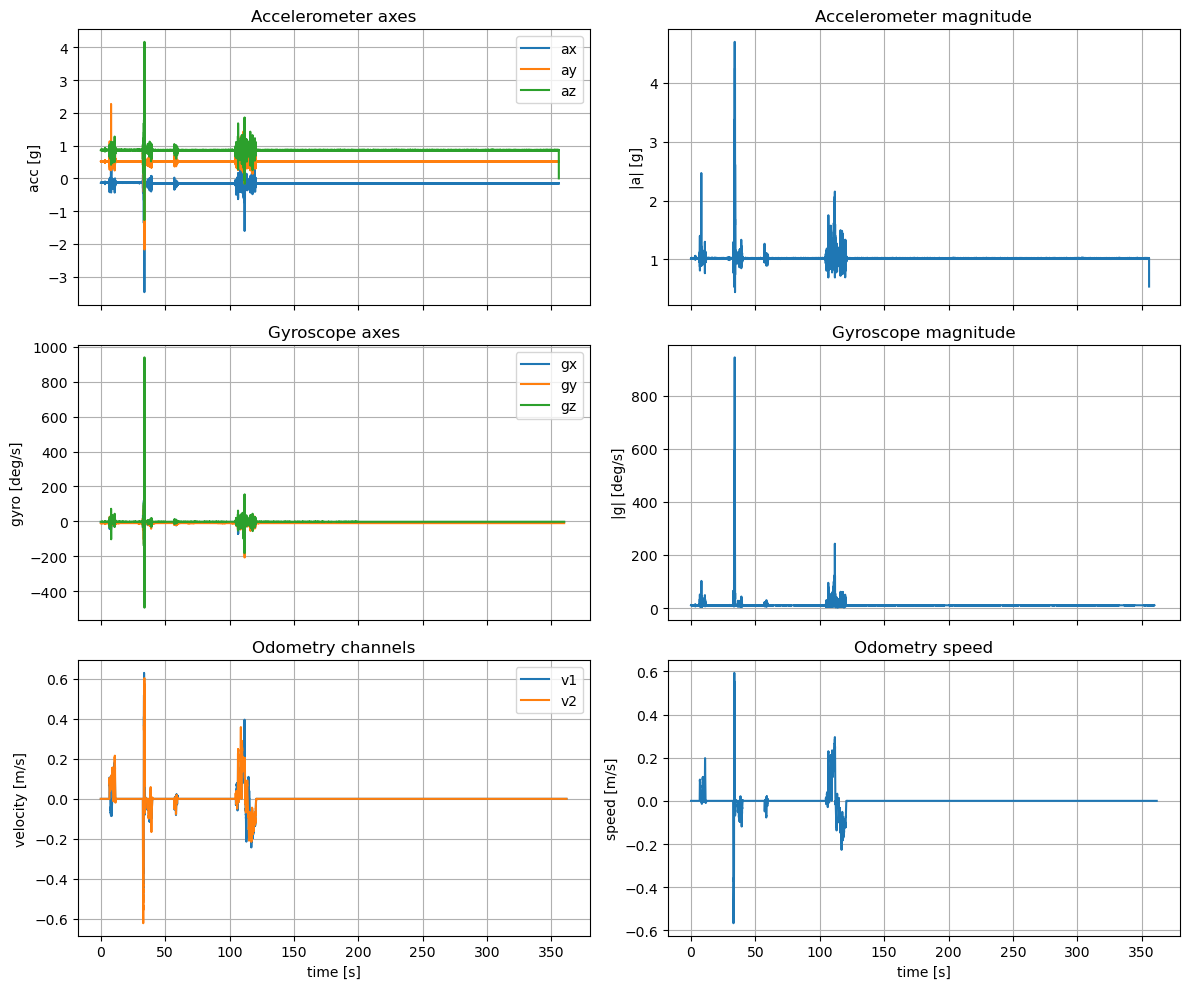

In [28]:
def plot_sanity(acc, gyro, odo, tcol='t_rel'):
    fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex='col')

    axes[0, 0].plot(acc[tcol], acc['ax'], label='ax')
    axes[0, 0].plot(acc[tcol], acc['ay'], label='ay')
    axes[0, 0].plot(acc[tcol], acc['az'], label='az')
    axes[0, 0].set_title('Accelerometer axes')
    axes[0, 0].set_ylabel('acc [g]')
    axes[0, 0].grid(True)
    axes[0, 0].legend()

    acc_mag = np.sqrt(acc['ax']**2 + acc['ay']**2 + acc['az']**2)
    axes[0, 1].plot(acc[tcol], acc_mag)
    axes[0, 1].set_title('Accelerometer magnitude')
    axes[0, 1].set_ylabel('|a| [g]')
    axes[0, 1].grid(True)

    axes[1, 0].plot(gyro[tcol], gyro['gx'], label='gx')
    axes[1, 0].plot(gyro[tcol], gyro['gy'], label='gy')
    axes[1, 0].plot(gyro[tcol], gyro['gz'], label='gz')
    axes[1, 0].set_title('Gyroscope axes')
    axes[1, 0].set_ylabel('gyro [deg/s]')
    axes[1, 0].grid(True)
    axes[1, 0].legend()

    gyro_mag = np.sqrt(gyro['gx']**2 + gyro['gy']**2 + gyro['gz']**2)
    axes[1, 1].plot(gyro[tcol], gyro_mag)
    axes[1, 1].set_title('Gyroscope magnitude')
    axes[1, 1].set_ylabel('|g| [deg/s]')
    axes[1, 1].grid(True)

    axes[2, 0].plot(odo[tcol], odo['v1'], label='v1')
    axes[2, 0].plot(odo[tcol], odo['v2'], label='v2')
    axes[2, 0].set_title('Odometry channels')
    axes[2, 0].set_xlabel('time [s]')
    axes[2, 0].set_ylabel('velocity [m/s]')
    axes[2, 0].grid(True)
    axes[2, 0].legend()

    speed = 0.5 * (odo['v1'] + odo['v2'])
    axes[2, 1].plot(odo[tcol], speed)
    axes[2, 1].set_title('Odometry speed')
    axes[2, 1].set_xlabel('time [s]')
    axes[2, 1].set_ylabel('speed [m/s]')
    axes[2, 1].grid(True)

    plt.tight_layout()
    plt.show()

plot_sanity(acc, gyro, odo)


In [29]:
def bias_from_first_seconds(df, cols, tcol='t_rel', seconds=5):
    seg = df[df[tcol] <= seconds]
    if seg.empty:
        return pd.Series(index=cols, dtype=float)
    return seg[cols].mean()

acc_mag = np.sqrt(acc['ax']**2 + acc['ay']**2 + acc['az']**2)
idle_mask = acc['t_rel'] <= 5

print('Gyro bias (first 5s):')
print(bias_from_first_seconds(gyro, ['gx', 'gy', 'gz']))
print('\nAcc mean (first 5s):')
print(bias_from_first_seconds(acc, ['ax', 'ay', 'az']))
print('\nAcc |a| median (first 5s):', float(np.median(acc_mag[idle_mask])) if idle_mask.any() else float('nan'))

def time_range(df, tcol='t_rel'):
    return float(df[tcol].min()), float(df[tcol].max())

print('\nTime ranges (t_rel):')
print('ACC ', time_range(acc))
print('GYRO', time_range(gyro))
print('ODO ', time_range(odo))


Gyro bias (first 5s):
gx   -3.516306
gy   -9.542891
gz   -1.699889
dtype: float64

Acc mean (first 5s):
ax   -0.135394
ay    0.516840
az    0.865484
dtype: float64

Acc |a| median (first 5s): 1.0171793548829036

Time ranges (t_rel):
ACC  (0.00020003318786621094, 355.7068998813629)
GYRO (0.0, 359.8210999965668)
ODO  (9.989738464355469e-05, 361.63380002975464)


In [ ]:
# Multi-run QC dashboard: one row per run, sensor-metric columns + hard pass/fail flags
RAW_ROOT = PROJECT_ROOT / 'data' / 'raw'
runs = load_runs(RAW_ROOT, include_pose=False)

# Hard QC thresholds (run-level pass requires all available sensors to pass)
MIN_DURATION_S = 30.0
EXPECTED_FS_RANGES = {
    'acc': (70.0, 100.0),
    'gyro': (70.0, 100.0),
    'odo': (100.0, 150.0),
}

rows = []
for r in runs:
    per_sensor = build_qc_report(r.sensors(), tcol='t_rel').set_index('sensor')

    # Keep the wide metric table (sensor__metric columns)
    wide = per_sensor.stack().rename('value').reset_index()
    wide['col'] = wide['sensor'] + '__' + wide['level_1']
    row = wide.set_index('col')['value'].to_dict()

    # Hard pass/fail flags
    gap_ok = (per_sensor['n_gaps_gt_factor_times_med'].fillna(1) == 0).all()
    dur_ok = (per_sensor['duration_s'].fillna(0) >= MIN_DURATION_S).all()

    fs_checks = []
    for sensor, stats in per_sensor.iterrows():
        fs = float(stats['fs_med_hz'])
        lo, hi = EXPECTED_FS_RANGES.get(sensor, (0.0, float('inf')))
        fs_checks.append(lo <= fs <= hi)
    fs_ok = all(fs_checks) if fs_checks else False

    row['run_id'] = r.run_id
    row['pass_dt_gaps'] = bool(gap_ok)
    row['pass_duration'] = bool(dur_ok)
    row['pass_fs'] = bool(fs_ok)
    row['pass_all'] = bool(gap_ok and dur_ok and fs_ok)
    rows.append(row)

dataset_qc = pd.DataFrame(rows).set_index('run_id').sort_index()
dataset_qc


,acc__n,acc__duration_s,acc__fs_med_hz,acc__dt_med,acc__dt_p99,acc__dt_max,acc__gap_ratio_dtmax_over_dtmed,acc__n_gaps_gt_factor_times_med,gyro__n,gyro__duration_s,gyro__fs_med_hz,gyro__dt_med,gyro__dt_p99,gyro__dt_max,gyro__gap_ratio_dtmax_over_dtmed,gyro__n_gaps_gt_factor_times_med,odo__n,odo__duration_s,odo__fs_med_hz,odo__dt_med,odo__dt_p99,odo__dt_max,odo__gap_ratio_dtmax_over_dtmed,odo__n_gaps_gt_factor_times_med,pass_dt_gaps,pass_duration,pass_fs,pass_all
run_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,
log_20251219_134611.366,5.0,0.0483,82.987327,0.01205,0.012197,0.0122,1.012435,0.0,5.0,0.0485,83.333578,0.012,0.013164,0.0132,1.100007,0.0,7.0,0.0483,128.203448,0.0078,0.0087,0.0087,1.115356,0.0,True,False,True,False
log_20251222_115149.656,24801.0,297.6012,83.334406,0.01200,0.013000,0.5222,43.517236,1.0,24801.0,297.6003,83.334406,0.012,0.013000,0.5222,43.517236,1.0,37201.0,297.6001,129.870696,0.0077,0.0088,0.5179,67.260032,1.0,False,True,True,False
log_20251222_120952.855,12437.0,149.2332,83.332751,0.01200,0.013000,0.0131,1.091671,0.0,12437.0,149.2343,83.332751,0.012,0.013000,0.0132,1.099996,0.0,18656.0,149.2401,129.870696,0.0077,0.0088,0.0097,1.259754,0.0,True,True,True,True
log_20260209_125910.654,29643.0,355.7067,83.332751,0.01200,0.013000,0.0172,1.433323,0.0,29986.0,359.8211,83.332751,0.012,0.013000,0.0170,1.416673,0.0,45205.0,361.6337,129.870696,0.0077,0.0088,0.0138,1.792234,0.0,True,True,True,True


In [35]:

# Fast filtering helpers
dataset_qc_good = dataset_qc[dataset_qc['pass_all']].copy()
dataset_qc_bad = dataset_qc[~dataset_qc['pass_all']].copy()

good_run_ids = dataset_qc_good.index.tolist()
bad_run_ids = dataset_qc_bad.index.tolist()

print('Good runs:', len(good_run_ids))
print(good_run_ids)
print('Bad runs:', len(bad_run_ids))
print(bad_run_ids)

dataset_qc_good



Good runs: 2
['log_20251222_120952.855', 'log_20260209_125910.654']
Bad runs: 2
['log_20251219_134611.366', 'log_20251222_115149.656']


,acc__n,acc__duration_s,acc__fs_med_hz,acc__dt_med,acc__dt_p99,acc__dt_max,acc__gap_ratio_dtmax_over_dtmed,acc__n_gaps_gt_factor_times_med,gyro__n,gyro__duration_s,gyro__fs_med_hz,gyro__dt_med,gyro__dt_p99,gyro__dt_max,gyro__gap_ratio_dtmax_over_dtmed,gyro__n_gaps_gt_factor_times_med,odo__n,odo__duration_s,odo__fs_med_hz,odo__dt_med,odo__dt_p99,odo__dt_max,odo__gap_ratio_dtmax_over_dtmed,odo__n_gaps_gt_factor_times_med,pass_dt_gaps,pass_duration,pass_fs,pass_all
run_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,
log_20251222_120952.855,12437.0,149.2332,83.332751,0.012,0.013,0.0131,1.091671,0.0,12437.0,149.2343,83.332751,0.012,0.013,0.0132,1.099996,0.0,18656.0,149.2401,129.870696,0.0077,0.0088,0.0097,1.259754,0.0,True,True,True,True
log_20260209_125910.654,29643.0,355.7067,83.332751,0.012,0.013,0.0172,1.433323,0.0,29986.0,359.8211,83.332751,0.012,0.013,0.0170,1.416673,0.0,45205.0,361.6337,129.870696,0.0077,0.0088,0.0138,1.792234,0.0,True,True,True,True
